In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib widget

In [2]:
omega0 = np.array((0, 0, 2))*2*np.pi
r0 = np.array((1, 0, 0))
eps = np.array((0, 1, 0))

def urychlena_rotace(_, y):
    r = y[:3]
    omega = y[3:]

    eps = np.cross(omega, np.array((2*np.pi, 0, 0)))

    ydot = np.concatenate([np.cross(omega, r), eps])
    return ydot

T_end = 5
reseni = solve_ivp(urychlena_rotace, t_span=(0, T_end), y0=np.concatenate([r0, omega0]), t_eval=np.arange(0, T_end, 0.01))

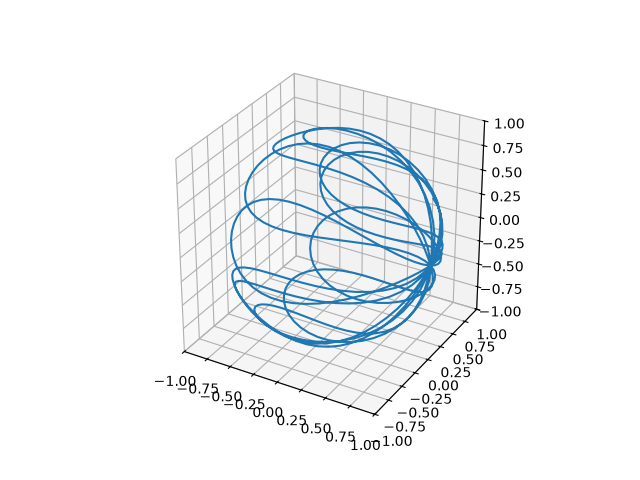

In [3]:
cas = reseni.t
omega = reseni.y[3:,:]
r = reseni.y[:3,:]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(*r)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_aspect('equal')

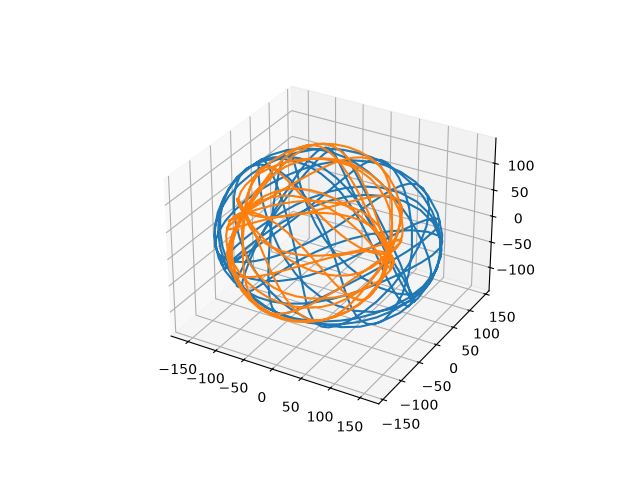

In [ ]:
rychlost = np.cross(omega, r, axis=0)
eps = np.cross(omega, np.array((2*np.pi, 0, 0)), axis=0)
akcelerace = np.cross(eps, r, axis=0) + np.cross(omega, rychlost, axis=0)

tecne_zrychleni = np.sum(akcelerace * rychlost, axis=0)*rychlost/np.linalg.norm(rychlost, axis=0)**2
normalove_zrychleni = akcelerace - tecne_zrychleni

omega_x_v = np.cross(omega, rychlost, axis=0)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot(*normalove_zrychleni)
ax.plot(*omega_x_v)

(500,) (500,)


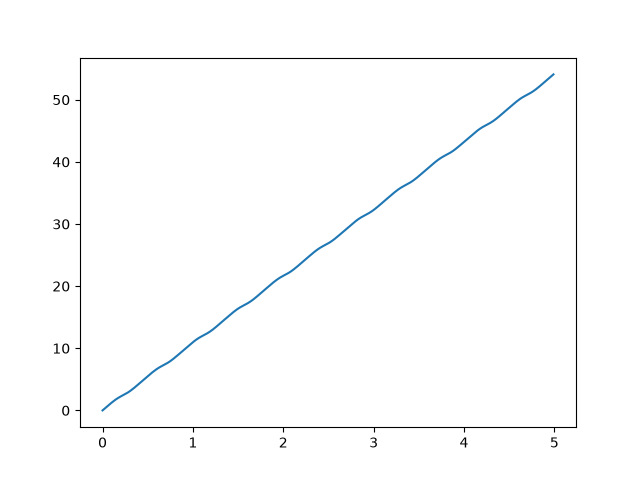

In [14]:
import scipy.integrate as intg
velikost_rychlosti = np.linalg.norm(rychlost, axis=0)
print(velikost_rychlosti.shape, cas.shape)
draha = intg.cumulative_trapezoid(velikost_rychlosti, cas, initial=0)

fig, ax = plt.subplots()
ax.plot(cas, draha)